In [1]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'
# ================= MODEL & SIMULATION PARAMETERS =================
#N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
model_names = ['nm', 'dcm', 'vcm']

In [8]:
distortion_params_2['N_dcs']

[12500, 15000, 17500, 20000, 22500, 25000]

In [ ]:
plt.cm.Reds(np.linspace(0.5, 0.85, 5))[-1]

array([[0.98357555, 0.41279508, 0.28835063, 1.        ],
       [0.95109573, 0.28558247, 0.2071511 , 1.        ],
       [0.88133795, 0.17700884, 0.14925029, 1.        ],
       [0.77854671, 0.0899654 , 0.1100346 , 1.        ],
       [0.67569396, 0.06560554, 0.08838139, 1.        ]])

Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-12500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-15000_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-17500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-20000_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-22500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/global/dcm_trials-100_shear-global_a-0_b-10_Ndc-25000_Nfvc-None.pkl


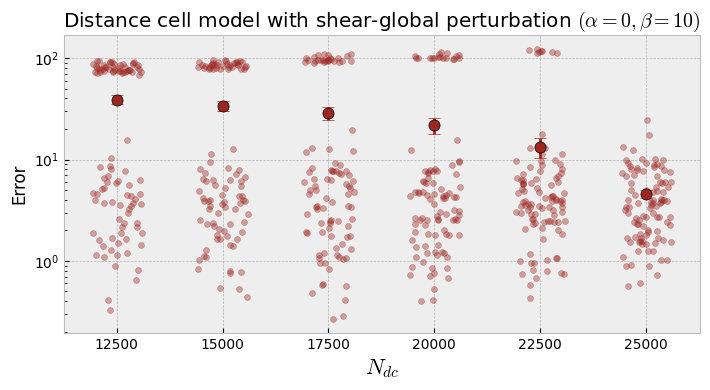

In [30]:
def plot_error_bar_2(distortion_params, n_trials, n_sim_round, model_name='dcm', target_location = [0,0]):
    distortion, a, b = distortion_params['distortion'], distortion_params['a'], distortion_params['b']
    distortion_name = distortion.split('-')[0]
    distortion_type = distortion.split('-')[1]
    N_dcs = distortion_params['N_dcs']
    output_dir = Path('simulation_outputs') / Path(f'round-{n_sim_round}') / Path(distortion_type)

    # Create condition names based on the parameter values
    conditions = [f'Ndc-{n_dcs}' for n_dcs in distortion_params['N_dcs']]

    # Calculate errors for each model x condition
    errors = {}
    for curr_condition in conditions:
        errors[curr_condition] = []
        found_file = False
        for f in os.listdir(output_dir):
            case_condition = curr_condition in f and distortion_name+'-' in f
            if f'{model_name}_trials-{n_trials}' in f and case_condition:
                found_file = True
                print('Reading file:', os.path.join(output_dir, f))
                x_histories, y_histories = pickle.load(open(os.path.join(output_dir, f), 'rb'))
                for x_history, y_history in zip(x_histories, y_histories):
                    final_x, final_y = x_history[-1], y_history[-1]
            #         print(f'({final_x:.2f}, {final_y:.2f}) with error {calculate_error([final_x, final_y], target_location):.2f}')
                    errors[curr_condition].append(calculate_error([final_x, final_y], target_location))
        if not found_file:
            print(f'ERROR: No file found for model={model_name}, condition={curr_condition}, trials={n_trials}.')
            return None

    # Plotting
    n_conditions = len(conditions)
    darkest_red = '#9E2621' # The darkest red in my Reds colormap
    bar_width = 0.8

    plt.figure(figsize=(n_conditions * 1.2, 4))
    all_se = []
    x_pos_list = []
    for cond_idx, condition in enumerate(conditions):
        error_list = errors[condition]
        #  print(f'Model: {model_name}, Condition: {condition}, Error mean: {np.mean(error_list)}')
        if len(error_list) == 0:
            continue

        x_pos = cond_idx - (n_conditions - 1) / 2
        x_pos_list.append(x_pos)
        # Mean +/- standard error bars
        se = np.std(error_list)/np.sqrt(len(error_list))
        all_se.append(se)
        plt.errorbar(x_pos, np.mean(error_list), yerr=se,
                        fmt='o', color=darkest_red, markersize=8, capsize=4,
                        markeredgecolor='black', markeredgewidth=0.5, zorder=3)

        # Individual points, jittered within the bar's slot so they don't overlap the next condition
        jitter = np.random.uniform(-bar_width * 0.3, bar_width * 0.3, size=len(error_list))
        plt.scatter(x_pos + jitter, error_list, alpha=0.4, color=darkest_red, s=18, zorder=2)

    plt.yscale('log')
    conditions = [cond.split('-')[1] for cond in conditions]
    plt.xticks(x_pos_list, conditions)
    plt.xlabel(r'$N_{dc}$', size=16)
    plt.ylabel('Error')
    plt.title(fr'Distance cell model with {distortion} perturbation $(\alpha={a}, \beta={b})$')
    plt.tight_layout()
    plt.show()

plot_error_bar_2(distortion_params_2, n_trials=N_TRIALS, n_sim_round=N_SIM_ROUND)

{'distortion': 'shear-local', 'a': 0, 'b': 0.5, 'b_drift': None, 'N_dcs': [12500, 15000, 17500, 20000, 22500, 25000]}
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-12500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-15000_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-17500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-20000_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-22500_Nfvc-None.pkl
Reading file: simulation_outputs/round-11/local/dcm_trials-100_shear-local_a-0_b-0.5_Ndc-25000_Nfvc-None.pkl


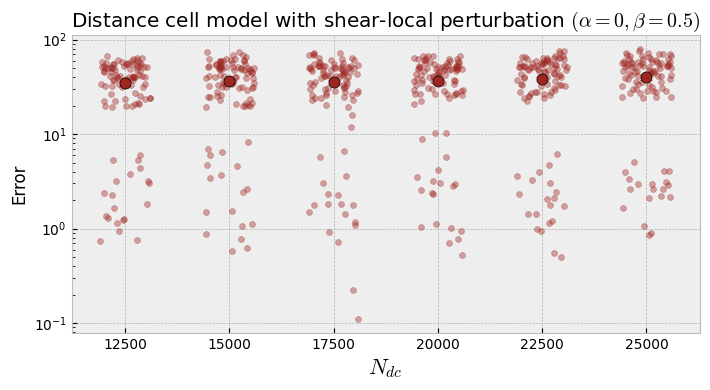


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


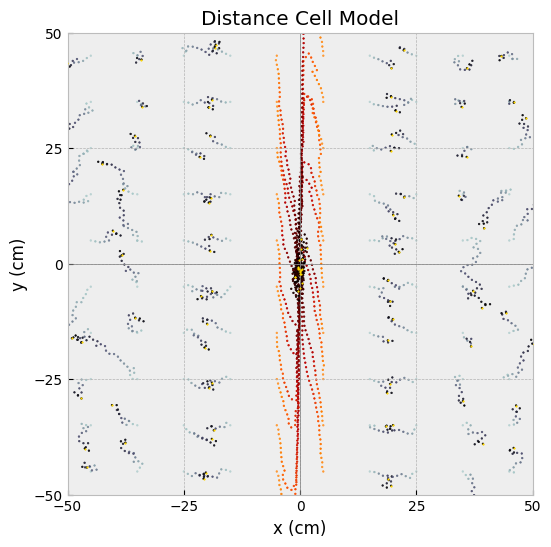

Successful trials: 20/100 (20.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


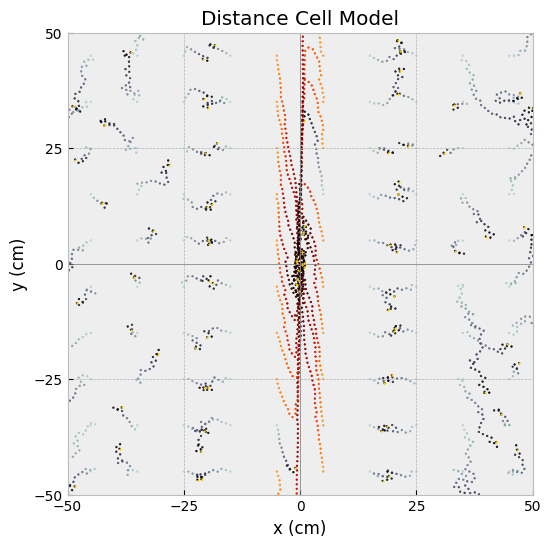

Successful trials: 18/100 (18.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


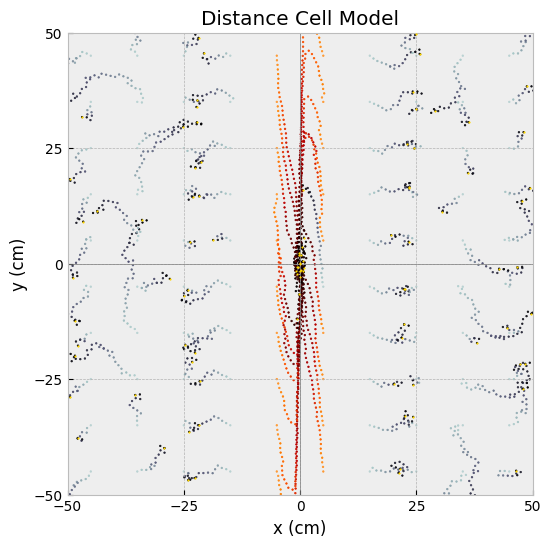

Successful trials: 19/100 (19.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


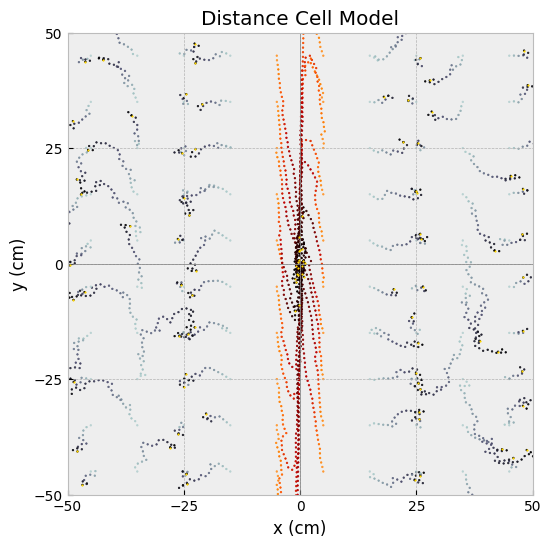

Successful trials: 20/100 (20.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


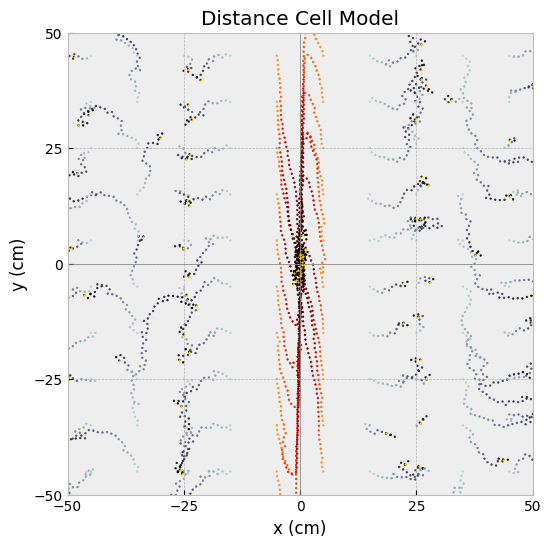

Successful trials: 20/100 (20.0%)

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-local-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


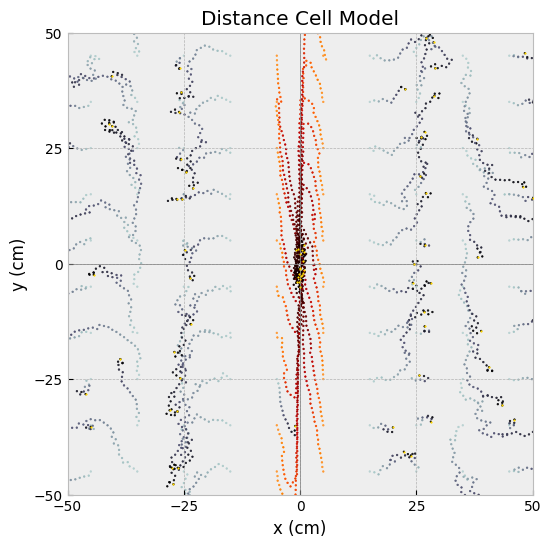

Successful trials: 19/100 (19.0%)


In [37]:
########################### EXTRA ANALYSIS ####################################
N_SIM_ROUND = 11
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5

model_name = 'dcm'
N_dcs = [12500, 15000, 17500, 20000, 22500, 25000]
###############################################################################
# Global distortion parameters
shear_drift_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 3, 5], 'b_drift': [0.1]}, 
                                     'shear+drift-global', incl_undistorted=False)

shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

# Local distortion parameters
shear_local_params = get_param_dict({'a': [0], 'b': [0, 0.05, 0.1, 0.3, 0.5]}, 
                                     'shear-local', incl_undistorted=False)
stretch_local_params = get_param_dict({'a': [1], 'b': [1, 0.99, 0.95, 0.9, 0.7]}, 
                                       'stretch-local', incl_undistorted=False)

# Modular distortion parameters
shear_modular_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                'shear-modular', incl_undistorted=False)
stretch_modular_params = get_param_dict({'a': [1], 'b': [0, 0.3, 0.5, 0.7, 0.9]},  # WARNING: Here b_final is 1 - b, so at b=0.5 we'd have b_M's = [0.99, 0.98, 0.97, 0.96, 0.93, 0.9 , 0.85, 0.78, 0.67, 0.5 ]
                                'stretch-modular', incl_undistorted=False)

stretch_simulations = [stretch_global_params, stretch_modular_params, stretch_local_params]
shear_simulations = [shear_global_params, shear_modular_params, shear_local_params, shear_drift_global_params]

shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
for curr_distortion_params in [shear_local_params]: #shear_simulations + stretch_simulations:
    largest_distortion_name = list(curr_distortion_params)[-1]
    distortion_params = curr_distortion_params[largest_distortion_name]
    distortion_params_2 = curr_distortion_params[largest_distortion_name].copy()
    distortion_params_2['N_dcs'] = N_dcs
    print(distortion_params_2)
    plot_error_bar_2(distortion_params_2, n_trials=N_TRIALS, n_sim_round=N_SIM_ROUND)

    if True:
        for curr_N_dc in N_dcs:
            # Only run for largest distortion
            print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={largest_distortion_name} {"-+" * 30}')

            x_histories, y_histories = run_load_simulation(model_name, 
                                                        arena_width=ARENA_WIDTH, 
                                                        step_size=STEP_SIZE,
                                                        convergence_threshold=CONV_THRESH,
                                                        n_trials=N_TRIALS, 
                                                        distortion_params=distortion_params,
                                                        n_sim_round=N_SIM_ROUND,
                                                        N_dc=curr_N_dc,
                                                        save_data=False)
            plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH)


### Projection of coordinate system into GC space

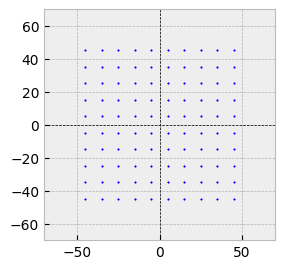

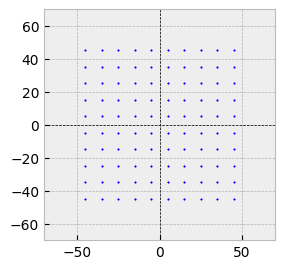

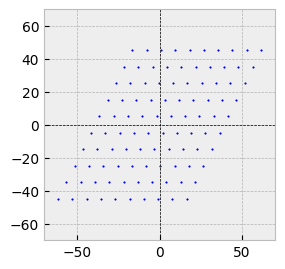

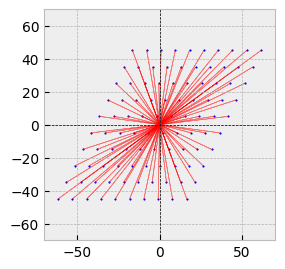

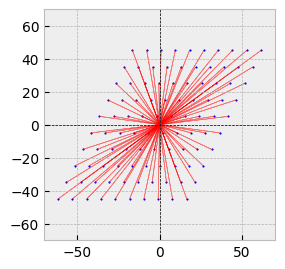

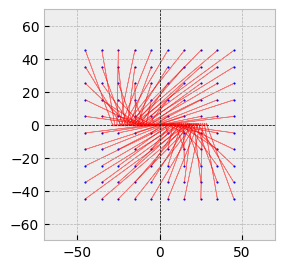

In [4]:
def plot_start_locations(X, Y, square_half_width, all_vecs = None, plot_vecs = False, title='Start Locations in Arena', distortion=False):
    plt.figure(figsize=(3, 3))
    if distortion == True and 'Grid Space' in title and False:
        X, Y = gc_distortion(X, Y, distortion='shear', a=0, b=1)
    plt.scatter(X, Y, c='blue', label='Start Locations', s=1)
    box_lim = 70
    plt.xlim(-box_lim, box_lim)
    plt.ylim(-box_lim, box_lim)
    # Calculate vector from each point to [0,0]
    no_loaded_all_vecs = all_vecs is None
    all_vecs = [] if no_loaded_all_vecs else all_vecs
    if plot_vecs:
        for i, (x, y) in enumerate(zip(X, Y)):
            if no_loaded_all_vecs:
                my_vec = - np.array([x, y])
                all_vecs.append(my_vec)
            else:
                my_vec = all_vecs[i]

                # Apply reverse distortion to the vector if distortion is applied
               # if distortion:
               #     print(f'Applying reverse distortion to vector {i}: {my_vec}')
               #     my_vec[0], my_vec[1] = gc_distortion(my_vec[0], my_vec[1], distortion='shear', a=0, b=2)
                # normalize
            plt.arrow(x, y, my_vec[0], my_vec[1], head_width=1, head_length=1, fc='red', ec='red', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
  #  plt.title(title)
  #  plt.xlabel('X')
  #  plt.ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    return all_vecs

    
# 1. Grid of start locations in real space
arena_width = 100
n_trials = 100

square_half_width = (arena_width / 2)
offset = 0.1 * square_half_width  # to avoid points on the edge

# Generate pos_xy_mat
XS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
YS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
PX, PY = np.meshgrid(XS, YS)
start_real = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space

_ = plot_start_locations(start_real[0, :], start_real[1, :], square_half_width, title='Original Start Locations in Real Space')
X_pert, Y_pert = gc_distortion(start_real[0, :], start_real[1, :], distortion='shear', a=0, b=10)
X_pert, Y_pert = start_real[0, :], start_real[1, :] # gc_distortion(start_real[0, :], start_real[1, :], distortion='shear', a=0, b=0.7)
start_pert_real = np.array([X_pert, Y_pert])  # (2, N) — evenly spaced in axis space
_ = plot_start_locations(start_pert_real[0, :], start_pert_real[1, :], square_half_width, title='Perturbed Start Locations in Real Space')

# Convert to real 2D positions to pass to navigation
start_pert_grid = real_to_grid_projection(start_pert_real, l1=1, l2=2)  # (2, N) — parallelogram in real space

_ = plot_start_locations(start_pert_grid[0, :], start_pert_grid[1, :], square_half_width,  plot_vecs=False, title='Perturbed Start Locations in Grid Space')

#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=False, title='Start Locations in Grid Space', distortion=True)
#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=True, title='Start Locations in Distorted Grid Space')
pert_vecs_grid = plot_start_locations(start_pert_grid[0, :], start_pert_grid[1, :], square_half_width,  plot_vecs=True, title='Perturbed Start Locations in Grid Space')
pert_vecs_grid = plot_start_locations(start_pert_grid[0, :], start_pert_grid[1, :], square_half_width,  plot_vecs=True, title='Perturbed Start Locations in Grid Space')

#vecs_grid = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width,  plot_vecs=True, all_vecs=vecs_grid, title='Start Locations in Grid Space', distortion=False)
pert_vecs_grid = np.array(pert_vecs_grid)

#_ = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width, title='Applying stretch distortion to Locations in Grid Space', distortion= True)

#grid_vecs = plot_start_locations(start_grid[0, :], start_grid[1, :], square_half_width, plot_vecs=True, title='Calculating Vectors in Grid Space', distortion= True)

#print('This should match my original start locations:')
#normal_grid_vecs = grid_to_real_projection(vecs_grid)

#real_grid_start_diff = start_real - start_grid
#goal_grid = vecs_grid + start_grid.T
#goal_real = real_to_grid_projection(goal_grid.T).T
#real_grid_goal_diff = goal_real - goal_grid
#corrected_normal_grid_vecs = vecs_grid - real_grid_start_diff.T  #+ real_grid_goal_diff


#pert_vecs_real = grid_to_real_projection(pert_vecs_grid.T).T
#_ = plot_start_locations(back_start_real[0, :], back_start_real[1, :], square_half_width, all_vecs=vecs_grid, plot_vecs=True, title='Back Projected Start Locations in Real Space')
_ = plot_start_locations(start_real[0, :], start_real[1, :], square_half_width, all_vecs=pert_vecs_grid, plot_vecs=True, title='Back Projected Start Locations in Real Space')


In [ ]:
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs.shape

(100, 2)


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.85it/s]


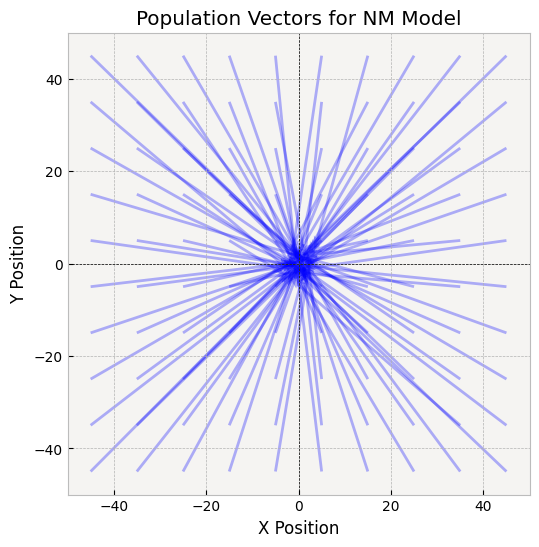


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 75.71it/s]


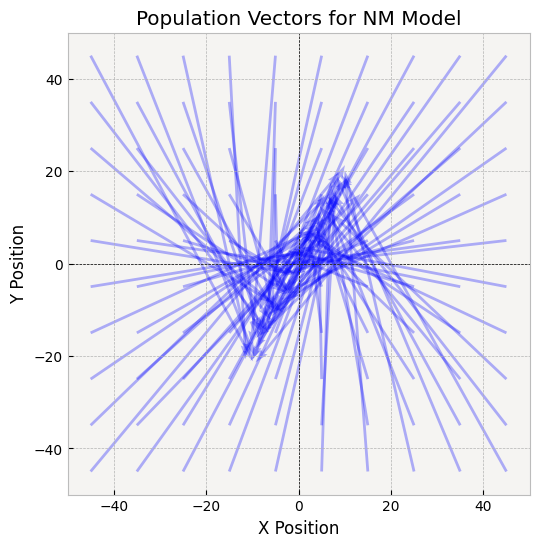


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.38it/s]


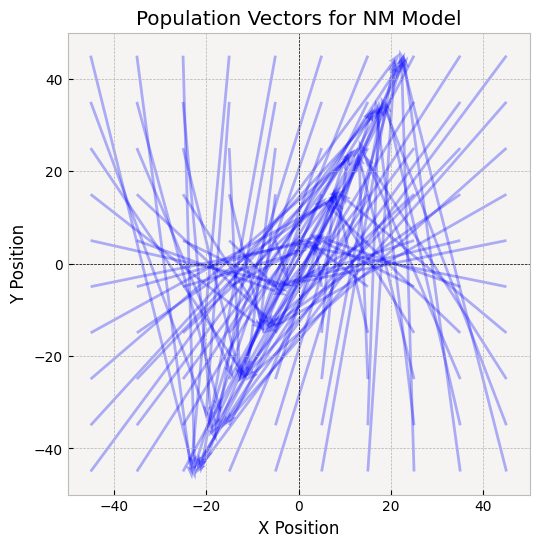


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-4 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.74it/s]


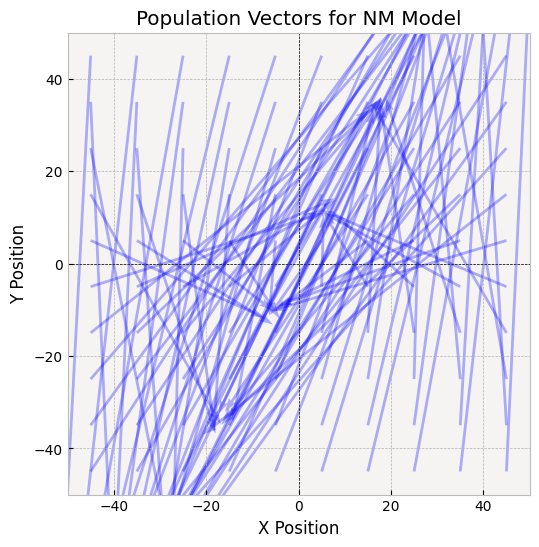


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch-global-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+


Simulating trials: 100%|██████████| 100/100 [00:01<00:00, 76.51it/s]


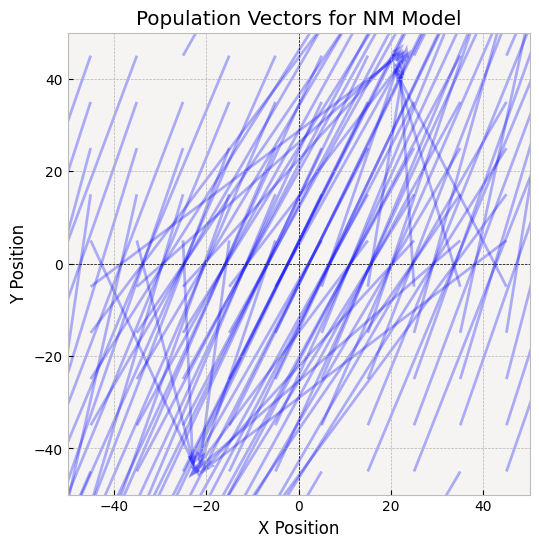

In [ ]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
# Set background color to antique white
plt.rcParams['axes.facecolor'] = "#F5F4F2"
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'

N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']


def pop_vec_simulation(model_name, arena_width, n_trials=400, step_size=0.1, convergence_threshold = 2.5, distortion_params = None, hexagonal_projection=False, n_sim_round=1, save_data=True):

    # Directories
    output_dir = Path('simulation_outputs', f'round-{n_sim_round}')
    distortion, a, b = distortion_params['distortion'], distortion_params['a'], distortion_params['b']
    distortion_type = distortion.split('-')[1]
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else '_undistorted'
    if '+drift' in distortion:
        distortion_text += f'_bdrift-{distortion_params["b_drift"]}'

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(distortion_params=distortion_params)
    elif model_name == 'vcm':
        model = VectorCellModel(distortion_params=distortion_params, arena_width = arena_width)
    elif model_name == 'nm':
        model = NestedModel(distortion_params=distortion_params)
    else:
        raise ValueError("Invalid model name")


    # Get evenly spaced start positions in real space
    border_offset = 0.05 * arena_width
    square_half_width = (arena_width / 2)
    offset_square_half_width = square_half_width - border_offset
    xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
    XS, YS = np.meshgrid(xs, ys)
    real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)

    # Get start positions in grid space
    if hexagonal_projection:
        grid_start_locs = real_to_grid_projection(np.array([XS.ravel(), YS.ravel()]) , l1=1, l2=2).T  
    
    # For each trial...
    pop_vec_histories = []
    for i in tqdm(range(n_trials), desc="Simulating trials"):

        # 1) Get start and goal positions 
        real_start_x, real_start_y = real_start_locs[i]
        grid_start_x, grid_start_y = grid_start_locs[i] if hexagonal_projection else (real_start_x, real_start_y)
        goal_x, goal_y = [0, 0] # Goal is the same in real and grid space
 
        # Compute the population vector based on the current position and the goal
        grid_start_x, grid_start_y = real_to_grid_projection([real_start_x, real_start_y]) if hexagonal_projection else (real_start_x, real_start_y)
        curr_pop_vec = model.forward(start_pos=[grid_start_x, grid_start_y], targ_pos=[goal_x, goal_y])
        curr_pop_vec = grid_to_real_projection(curr_pop_vec) if hexagonal_projection else curr_pop_vec
        pop_vec_histories.append(curr_pop_vec)

    # Plot pop_vec_histories
    pop_vec_histories = np.array(pop_vec_histories)
    plt.figure(figsize=(6, 6))
    plt.quiver(real_start_locs[:, 0], real_start_locs[:, 1], pop_vec_histories[:, 0], pop_vec_histories[:, 1], angles='xy', scale_units='xy', color='blue', alpha=0.3, scale=1)
  #  plt.scatter(real_start_locs[:, 0] - pop_vec_histories[:, 0],real_start_locs[:, 1] - pop_vec_histories[:, 1], c='red', s=1, label='Population Vector Endpoints')


    plt.xlim(-square_half_width, square_half_width)
    plt.ylim(-square_half_width, square_half_width)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.title(f'Population Vectors for {model_name.upper()} Model')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)
    plt.show()
stretch_global_params = get_param_dict({'a': [1], 'b': [1, 0.7, 0.5, 0.3, 0.1]}, 
                                       'stretch-global', incl_undistorted=False)

selected_distortion_params = stretch_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in ['nm']:
        pop_vec_simulation(model_name, 
                            arena_width=ARENA_WIDTH, 
                            step_size=STEP_SIZE,
                            convergence_threshold=CONV_THRESH,
                            n_trials=100, 
                            distortion_params=selected_distortion_params[distortion_name],
                            hexagonal_projection=True,
                            n_sim_round= N_SIM_ROUND,
                            save_data=False)